# Garbage Classification with InceptionV3
## Deep Learning Project

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import os

In [2]:
torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
DATA_DIR = r"C:\Users\Lenovo\Desktop\Garbage_Classification_Project\garbage-dataset-split"

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), test_transform)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), test_transform)

num_classes = len(train_dataset.classes)
print(num_classes)

10


In [8]:

from torch.utils.data import DataLoader

# GPU'ya güvenli yük (16)
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("✅ DataLoader hazır (etkili batch size = 32)")

✅ DataLoader hazır (etkili batch size = 32)


In [9]:
ACCUMULATION_STEPS = 2

In [10]:
import torch.nn as nn
from torchvision import models

model = models.inception_v3(
    weights=models.Inception_V3_Weights.DEFAULT,
    aux_logits=True
)

# Backbone'u dondur (OOM riskini bitirir)
for param in model.parameters():
    param.requires_grad = False

# Son katmanı 10 sınıfa ayarla
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

print("✅ InceptionV3 hazır (batch 32 uyumlu)")

✅ InceptionV3 hazır (batch 32 uyumlu)


In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),   # sadece FC eğitiliyor
    lr=1e-4
)

print("✅ Loss ve Optimizer hazır")

✅ Loss ve Optimizer hazır


In [12]:
def train_model(model, train_loader, val_loader, epochs):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        optimizer.zero_grad()

        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)  # <-- outputs BURADA TANIMLANIYOR
            logits = outputs.logits if hasattr(outputs, "logits") else outputs

            loss = criterion(logits, labels)
            loss = loss / ACCUMULATION_STEPS
            loss.backward()

            if (i + 1) % ACCUMULATION_STEPS == 0:
                optimizer.step()
                optimizer.zero_grad()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        # -------- VALIDATION --------
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)  # <-- burada da
                logits = outputs.logits if hasattr(outputs, "logits") else outputs

                loss = criterion(logits, labels)
                val_loss += loss.item()

        val_loss /= len(val_loader)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

In [13]:
train_model(model, train_loader, val_loader, epochs=20)

Epoch [1/20] | Train Loss: 0.7731 | Val Loss: 1.0895
Epoch [2/20] | Train Loss: 0.4646 | Val Loss: 0.7572
Epoch [3/20] | Train Loss: 0.3609 | Val Loss: 0.6077
Epoch [4/20] | Train Loss: 0.3142 | Val Loss: 0.5354
Epoch [5/20] | Train Loss: 0.2840 | Val Loss: 0.4956
Epoch [6/20] | Train Loss: 0.2637 | Val Loss: 0.4598
Epoch [7/20] | Train Loss: 0.2500 | Val Loss: 0.4347
Epoch [8/20] | Train Loss: 0.2360 | Val Loss: 0.4048
Epoch [9/20] | Train Loss: 0.2305 | Val Loss: 0.3882
Epoch [10/20] | Train Loss: 0.2238 | Val Loss: 0.3788
Epoch [11/20] | Train Loss: 0.2199 | Val Loss: 0.3769
Epoch [12/20] | Train Loss: 0.2170 | Val Loss: 0.3549
Epoch [13/20] | Train Loss: 0.2110 | Val Loss: 0.3691
Epoch [14/20] | Train Loss: 0.2026 | Val Loss: 0.3416
Epoch [15/20] | Train Loss: 0.2037 | Val Loss: 0.3387
Epoch [16/20] | Train Loss: 0.2013 | Val Loss: 0.3363
Epoch [17/20] | Train Loss: 0.2033 | Val Loss: 0.3307
Epoch [18/20] | Train Loss: 0.1926 | Val Loss: 0.3189
Epoch [19/20] | Train Loss: 0.1982 | 

In [14]:
test_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "test"),
    transform=test_transform
)

print("Test örnek sayısı:", len(test_dataset))

Test örnek sayısı: 2974


In [15]:
test_loader = DataLoader(
    test_dataset,
    batch_size=16,      # GPU güvenli, eğitimle uyumlu
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("✅ test_loader hazır")

✅ test_loader hazır


In [16]:
import numpy as np
import torch.nn.functional as F

model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        logits = outputs.logits if hasattr(outputs, "logits") else outputs

        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("✅ Test tahminleri alındı")

✅ Test tahminleri alındı


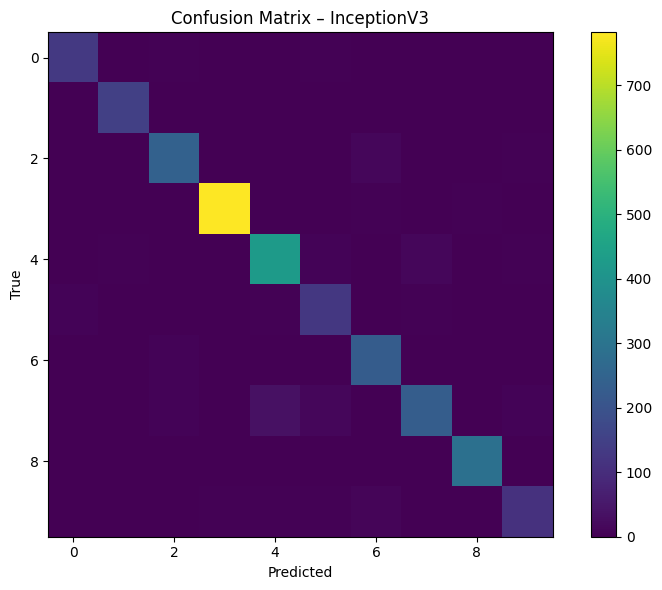

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix – InceptionV3")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

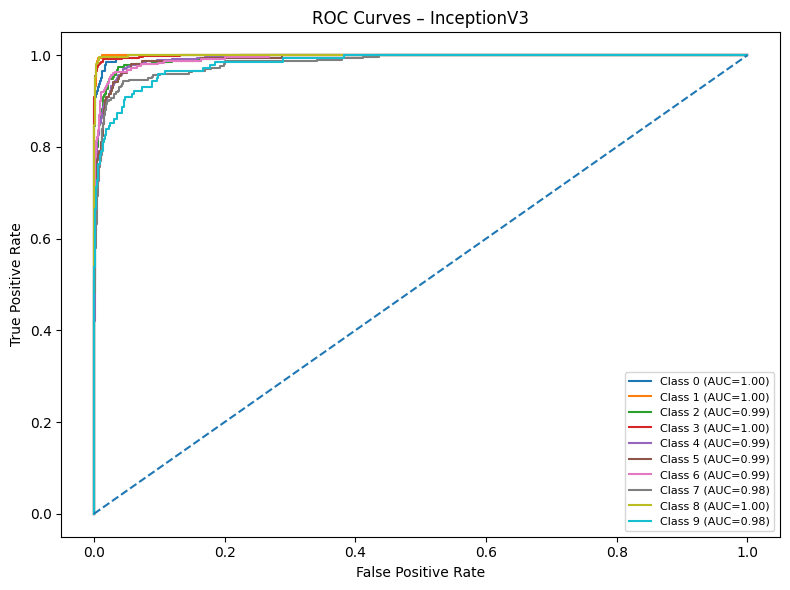

In [18]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = len(np.unique(y_true))
y_true_bin = label_binarize(y_true, classes=range(n_classes))

plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – InceptionV3")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [19]:
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, roc_auc_score

acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")
weighted_f1 = f1_score(y_true, y_pred, average="weighted")
kappa = cohen_kappa_score(y_true, y_pred)
roc_auc_macro = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
roc_auc_weighted = roc_auc_score(y_true, y_prob, multi_class="ovr", average="weighted")

print(f"Accuracy: {acc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")
print(f"Cohen Kappa: {kappa:.4f}")
print(f"ROC AUC (Macro): {roc_auc_macro:.4f}")
print(f"ROC AUC (Weighted): {roc_auc_weighted:.4f}")

Accuracy: 0.9136
Macro F1: 0.8910
Weighted F1: 0.9131
Cohen Kappa: 0.8993
ROC AUC (Macro): 0.9934
ROC AUC (Weighted): 0.9944


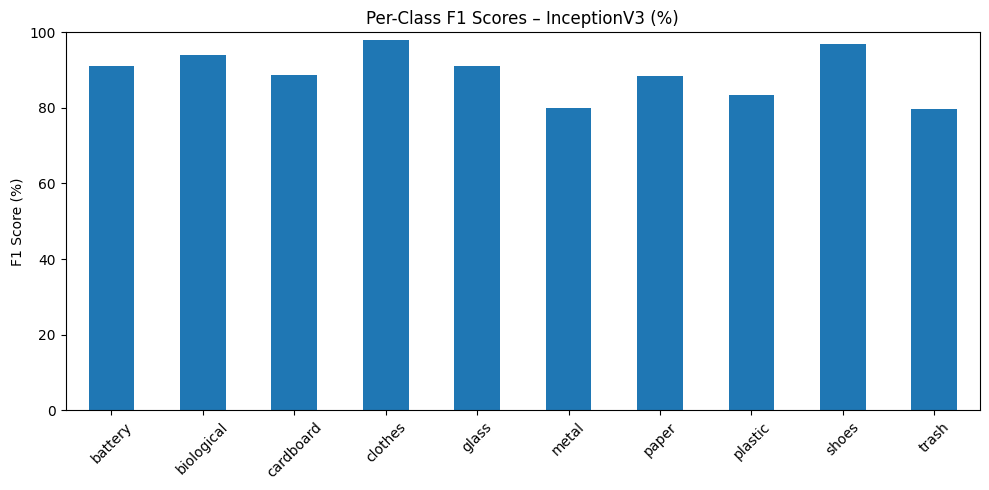

In [23]:
df_f1.plot(kind="bar", figsize=(10,5), legend=False)
plt.title("Per-Class F1 Scores – InceptionV3 (%)")
plt.ylabel("F1 Score (%)")
plt.ylim(0,100)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


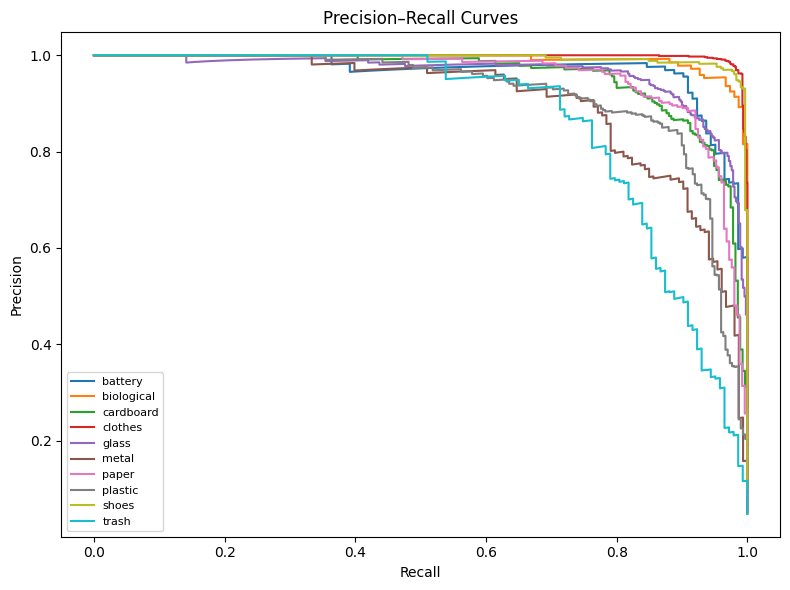

In [26]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))
for i in range(len(train_dataset.classes)):
    precision, recall, _ = precision_recall_curve(
        y_true == i, y_prob[:, i]
    )
    plt.plot(recall, precision, label=train_dataset.classes[i])

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

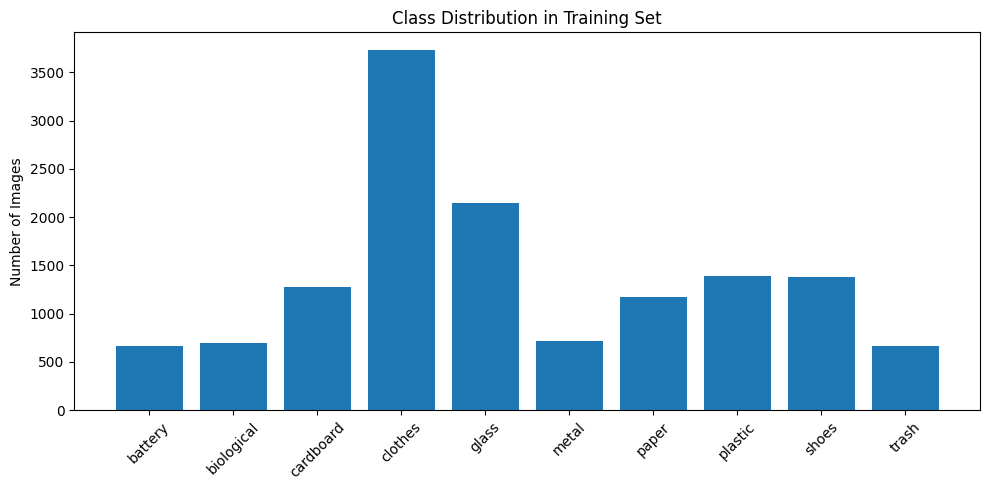

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

labels = [label for _, label in train_dataset.samples]
label_counts = Counter(labels)

class_names = train_dataset.classes
counts = [label_counts[i] for i in range(len(class_names))]

plt.figure(figsize=(10,5))
plt.bar(class_names, counts)
plt.xticks(rotation=45)
plt.title("Class Distribution in Training Set")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

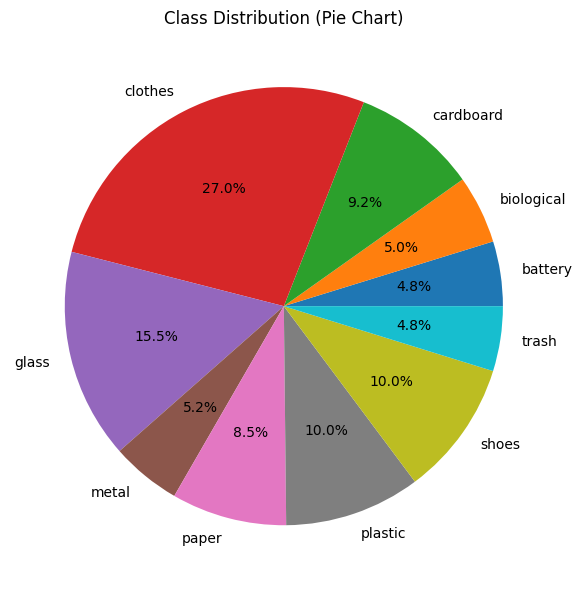

In [28]:
plt.figure(figsize=(6,6))
plt.pie(counts, labels=class_names, autopct='%1.1f%%')
plt.title("Class Distribution (Pie Chart)")
plt.tight_layout()
plt.show()

In [29]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Test tahminleri tekrar alındı ✅")
print("Örnek sayısı:", len(all_labels))


Test tahminleri tekrar alındı ✅
Örnek sayısı: 2974


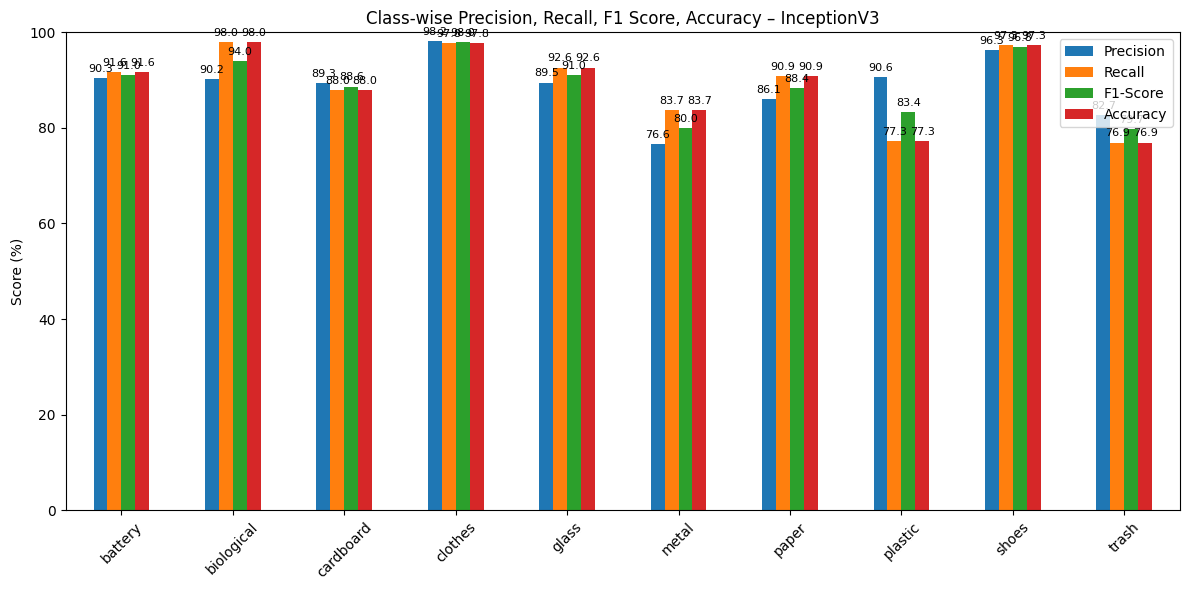

In [32]:
import matplotlib.pyplot as plt

ax = df_metrics.plot(kind="bar", figsize=(12,6))
plt.title("Class-wise Precision, Recall, F1 Score, Accuracy – InceptionV3")
plt.ylabel("Score (%)")
plt.ylim(0,100)
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3, fontsize=8)

plt.tight_layout()
plt.show()


In [33]:
from sklearn.model_selection import StratifiedKFold
from collections import Counter
import numpy as np

# ImageFolder'dan label'ları al
labels = [label for _, label in train_dataset.samples]
labels = np.array(labels)

# Dummy X (görüntü yolu yerine index yeterli)
X = np.arange(len(labels))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("📊 StratifiedKFold – Sınıf Dağılımları\n")

for fold, (train_idx, test_idx) in enumerate(skf.split(X, labels), 1):
    train_labels = labels[train_idx]
    test_labels = labels[test_idx]

    print(f"Fold {fold}")
    print(" Train:", Counter(train_labels))
    print(" Test :", Counter(test_labels))
    print("-" * 50)

📊 StratifiedKFold – Sınıf Dağılımları

Fold 1
 Train: Counter({np.int64(3): 2982, np.int64(4): 1714, np.int64(7): 1110, np.int64(8): 1107, np.int64(2): 1022, np.int64(6): 941, np.int64(5): 571, np.int64(1): 557, np.int64(9): 529, np.int64(0): 528})
 Test : Counter({np.int64(3): 746, np.int64(4): 428, np.int64(7): 278, np.int64(8): 276, np.int64(2): 255, np.int64(6): 235, np.int64(5): 143, np.int64(1): 140, np.int64(9): 133, np.int64(0): 132})
--------------------------------------------------
Fold 2
 Train: Counter({np.int64(3): 2982, np.int64(4): 1714, np.int64(7): 1110, np.int64(8): 1107, np.int64(2): 1022, np.int64(6): 941, np.int64(5): 571, np.int64(1): 557, np.int64(9): 529, np.int64(0): 528})
 Test : Counter({np.int64(3): 746, np.int64(4): 428, np.int64(7): 278, np.int64(8): 276, np.int64(2): 255, np.int64(6): 235, np.int64(5): 143, np.int64(1): 140, np.int64(9): 133, np.int64(0): 132})
--------------------------------------------------
Fold 3
 Train: Counter({np.int64(3): 2983, 

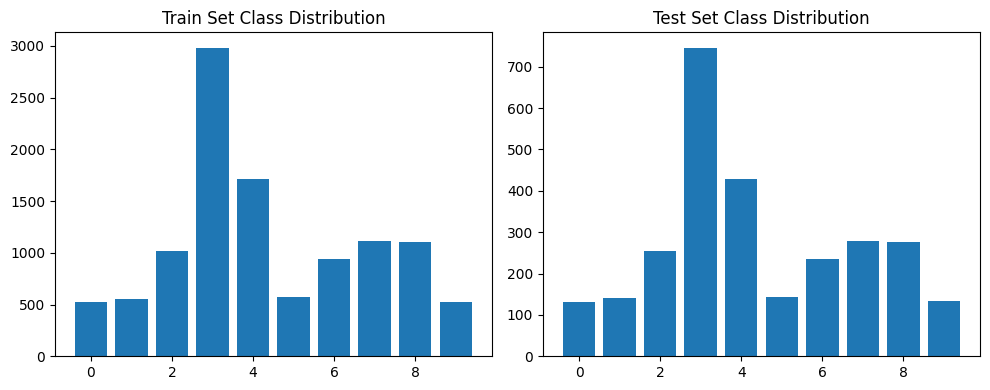

In [34]:
import matplotlib.pyplot as plt

# İlk fold'u görselleştirelim
train_idx, test_idx = next(skf.split(X, labels))

train_labels = labels[train_idx]
test_labels = labels[test_idx]

train_counts = Counter(train_labels)
test_counts = Counter(test_labels)

classes = list(train_counts.keys())
train_vals = [train_counts[c] for c in classes]
test_vals = [test_counts[c] for c in classes]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.bar(classes, train_vals)
plt.title("Train Set Class Distribution")

plt.subplot(1,2,2)
plt.bar(classes, test_vals)
plt.title("Test Set Class Distribution")

plt.tight_layout()
plt.show()

In [35]:
from sklearn.model_selection import train_test_split

X_idx = np.arange(len(labels))
y = labels

# Önce train + temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_idx, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Sonra val + test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train distribution:", Counter(y_train))
print("Val distribution  :", Counter(y_val))
print("Test distribution :", Counter(y_test))

Train distribution: Counter({np.int64(3): 2609, np.int64(4): 1499, np.int64(7): 972, np.int64(8): 968, np.int64(2): 894, np.int64(6): 823, np.int64(5): 500, np.int64(1): 488, np.int64(9): 463, np.int64(0): 462})
Val distribution  : Counter({np.int64(3): 559, np.int64(4): 321, np.int64(7): 208, np.int64(8): 207, np.int64(2): 191, np.int64(6): 177, np.int64(5): 107, np.int64(1): 105, np.int64(9): 100, np.int64(0): 99})
Test distribution : Counter({np.int64(3): 560, np.int64(4): 322, np.int64(8): 208, np.int64(7): 208, np.int64(2): 192, np.int64(6): 176, np.int64(5): 107, np.int64(1): 104, np.int64(0): 99, np.int64(9): 99})


In [36]:
import pandas as pd

data = {
    "Set": ["Train", "Validation", "Test"],
    "Sample Count": [len(y_train), len(y_val), len(y_test)]
}

df = pd.DataFrame(data)
df

,Set,Sample Count
0,Train,9678
1,Validation,2074
2,Test,2075


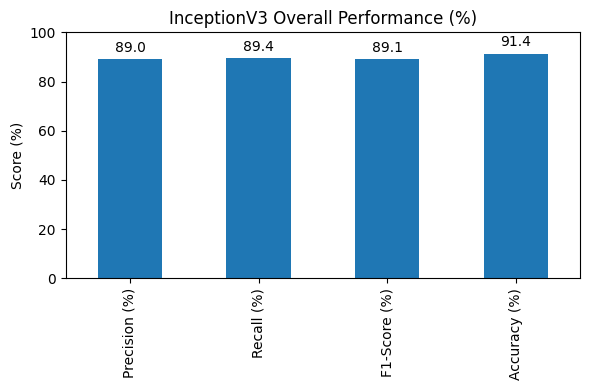

In [45]:
import matplotlib.pyplot as plt

ax = overall_metrics.T.plot(kind="bar", legend=False, figsize=(6,4))
plt.title("InceptionV3 Overall Performance (%)")
plt.ylabel("Score (%)")
plt.ylim(0,100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.tight_layout()
plt.show()


In [46]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
class_names = train_dataset.classes

# ---------- SINIF BAZLI METRİKLER ----------
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

df_class = pd.DataFrame(report).T.iloc[:-3, :3]
df_class.columns = ["Precision", "Recall", "F1-Score"]

cm = confusion_matrix(y_true, y_pred)
class_accuracy = cm.diagonal() / cm.sum(axis=1)
df_class["Accuracy"] = class_accuracy

df_class = df_class * 100

print("🔹 Class-wise Performance (%)")
display(df_class.style.background_gradient(cmap="YlGnBu").format("{:.2f}"))

# ---------- GENEL METRİKLER ----------
df_overall = pd.DataFrame({
    "Precision": [precision_score(y_true, y_pred, average="macro") * 100],
    "Recall": [recall_score(y_true, y_pred, average="macro") * 100],
    "F1-Score": [f1_score(y_true, y_pred, average="macro") * 100],
    "Accuracy": [accuracy_score(y_true, y_pred) * 100]
}, index=["InceptionV3"])

print("\n🔹 Overall Model Performance (%)")
display(df_overall.style.background_gradient(cmap="Greens").format("{:.2f}"))


🔹 Class-wise Performance (%)


,Precision,Recall,F1-Score,Accuracy
battery,90.34,91.61,90.97,91.61
biological,90.24,98.01,93.97,98.01
cardboard,89.30,88.00,88.64,88.00
clothes,98.24,97.75,97.99,97.75
glass,89.50,92.61,91.03,92.61
metal,76.65,83.66,80.00,83.66
paper,86.09,90.87,88.42,90.87
plastic,90.59,77.26,83.39,77.26
shoes,96.35,97.32,96.83,97.32
trash,82.71,76.92,79.71,76.92



🔹 Overall Model Performance (%)


,Precision,Recall,F1-Score,Accuracy
InceptionV3,89.00,89.40,89.10,91.36


In [1]:
import pandas as pd

data = {
    "Model": ["Base CNN", "InceptionV3", "ResNet50"],
    "Precision (%)": [48.865545, 89.00, 91.700741],
    "Recall (%)":    [69.903895, 89.40, 91.324815],
    "F1-Score (%)":  [57.521395, 89.10, 91.33827],
    "Accuracy (%)":  [69.903895, 91.36, 91.324815]
}

df_models = pd.DataFrame(data)

styled_table = (
    df_models.style
    .background_gradient(cmap="Oranges", subset=["Precision (%)","Recall (%)","F1-Score (%)","Accuracy (%)"])
    
    .highlight_max(
        subset=["Precision (%)","Recall (%)","F1-Score (%)","Accuracy (%)"],
        color="#D35400" 
    )
    
    .apply(lambda row: ['font-weight: bold' if row.name == df_models["Accuracy (%)"].idxmax() else '' for _ in row], axis=1)
    
    .set_properties(**{
        'text-align': 'center',
        'font-size': '12pt'
    })
    
    .set_caption("Model Performance Comparison")
)

styled_table


,Model,Precision (%),Recall (%),F1-Score (%),Accuracy (%)
0,Base CNN,48.865545,69.903895,57.521395,69.903895
1,InceptionV3,89.000000,89.400000,89.100000,91.360000
2,ResNet50,91.700741,91.324815,91.338270,91.324815


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].


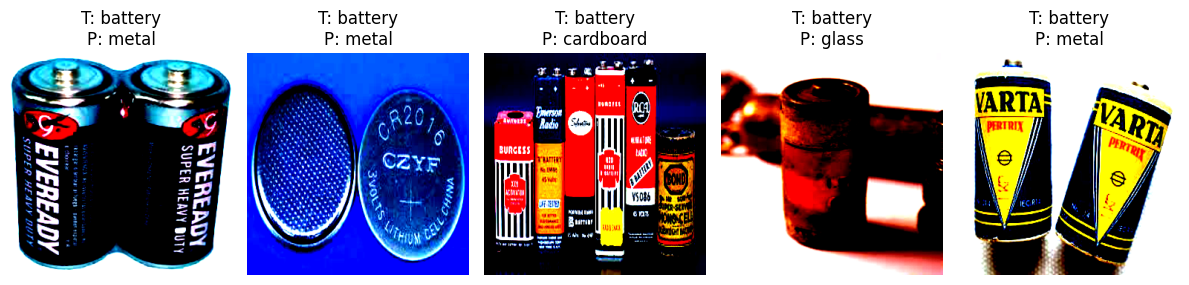

In [37]:
import numpy as np
import matplotlib.pyplot as plt

wrong_idx = np.where(y_true != y_pred)[0][:5]

plt.figure(figsize=(12,4))
for i, idx in enumerate(wrong_idx):
    img, _ = test_dataset[idx]
    img = img.permute(1,2,0).numpy()

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(
        f"T: {train_dataset.classes[y_true[idx]]}\n"
        f"P: {train_dataset.classes[y_pred[idx]]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5179958].
Clipping in

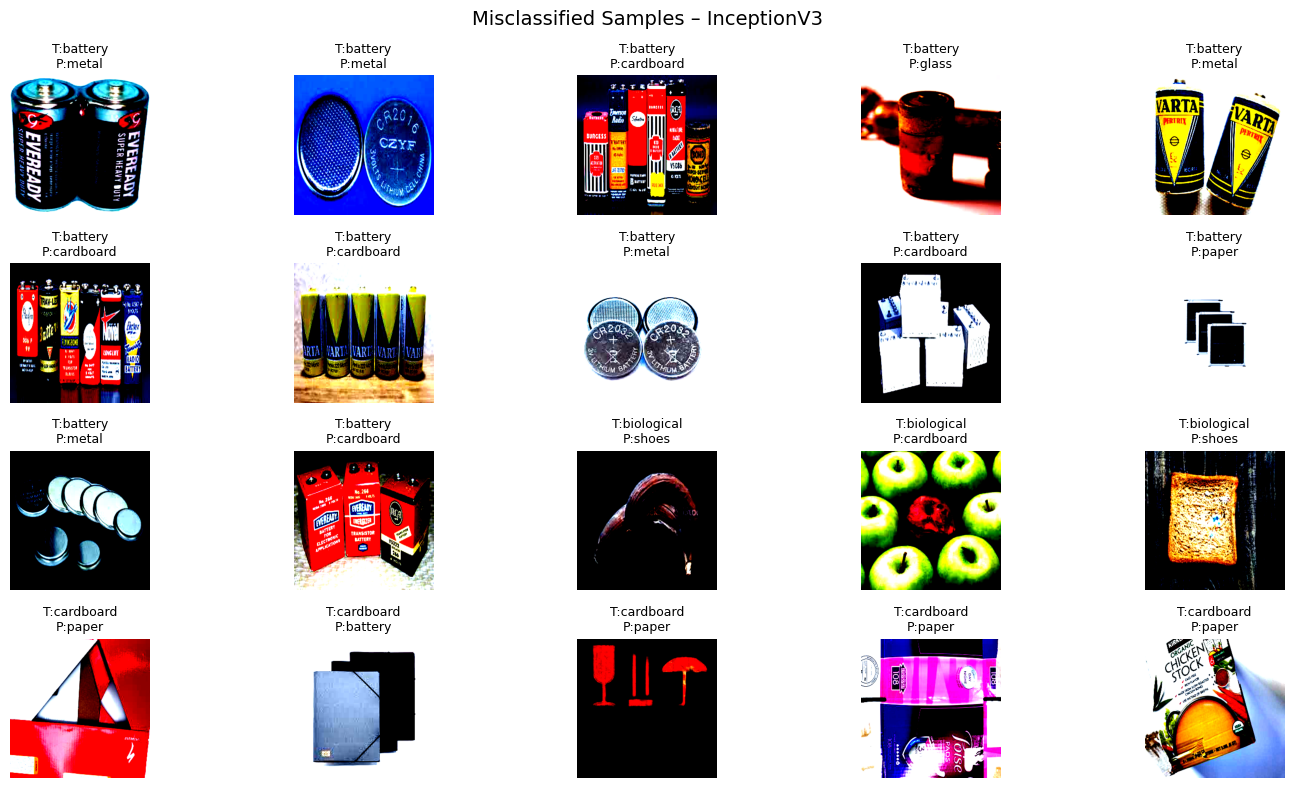

In [38]:
wrong_idx = np.where(y_true != y_pred)[0][:20]

plt.figure(figsize=(15,8))
for i, idx in enumerate(wrong_idx):
    img, _ = test_dataset[idx]
    img = img.permute(1,2,0).numpy()

    plt.subplot(4,5,i+1)
    plt.imshow(img)
    plt.title(
        f"T:{train_dataset.classes[y_true[idx]]}\n"
        f"P:{train_dataset.classes[y_pred[idx]]}",
        fontsize=9
    )
    plt.axis("off")

plt.suptitle("Misclassified Samples – InceptionV3", fontsize=14)
plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6555357..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8096584..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.9988013].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0776608].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3815396..2.64].
Clipping input

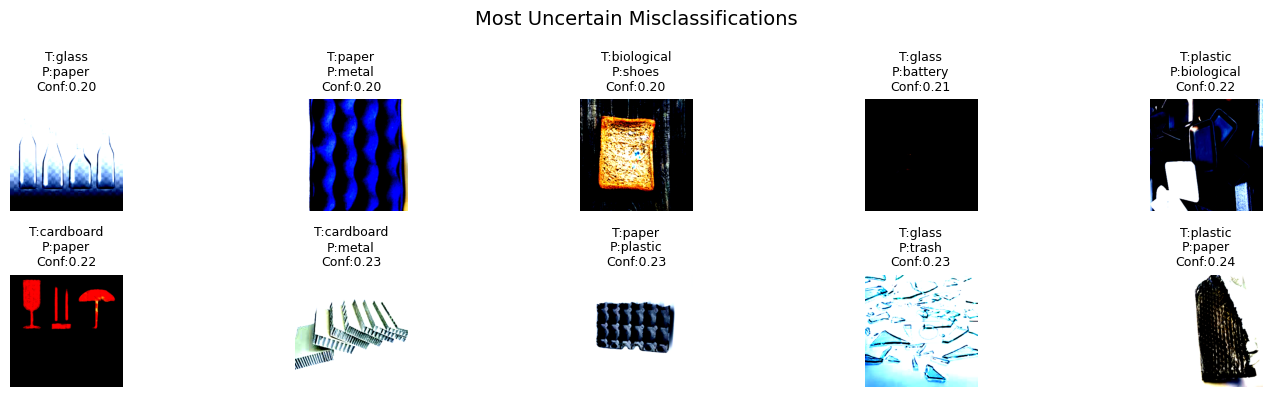

In [39]:
# Yanlış ama en düşük confidence ile yapılanlar
confidences = np.max(y_prob, axis=1)
wrong_idx = np.where(y_true != y_pred)[0]

# En kararsız 10 yanlış
uncertain_wrong = wrong_idx[np.argsort(confidences[wrong_idx])][:10]

plt.figure(figsize=(15,4))
for i, idx in enumerate(uncertain_wrong):
    img, _ = test_dataset[idx]
    img = img.permute(1,2,0).numpy()

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(
        f"T:{train_dataset.classes[y_true[idx]]}\n"
        f"P:{train_dataset.classes[y_pred[idx]]}\n"
        f"Conf:{confidences[idx]:.2f}",
        fontsize=9
    )
    plt.axis("off")

plt.suptitle("Most Uncertain Misclassifications", fontsize=14)
plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7582842..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.55955136..2.5528543].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8952821..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8956583..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.55955136..2.64].
Clipping in

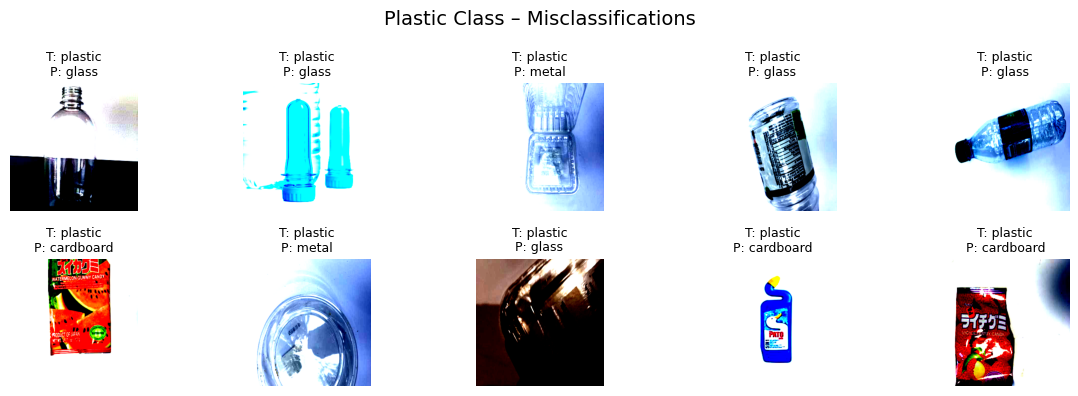

In [40]:
target_class = train_dataset.classes.index("plastic")

filtered = [
    i for i in range(len(y_true))
    if y_true[i] == target_class and y_pred[i] != target_class
][:10]

plt.figure(figsize=(12,4))
for i, idx in enumerate(filtered):
    img, _ = test_dataset[idx]
    img = img.permute(1,2,0).numpy()

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(
        f"T: plastic\nP: {train_dataset.classes[y_pred[idx]]}",
        fontsize=9
    )
    plt.axis("off")

plt.suptitle("Plastic Class – Misclassifications", fontsize=14)
plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.465708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8267832..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5179958].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.843908..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.3262744].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.64].
Clipping 

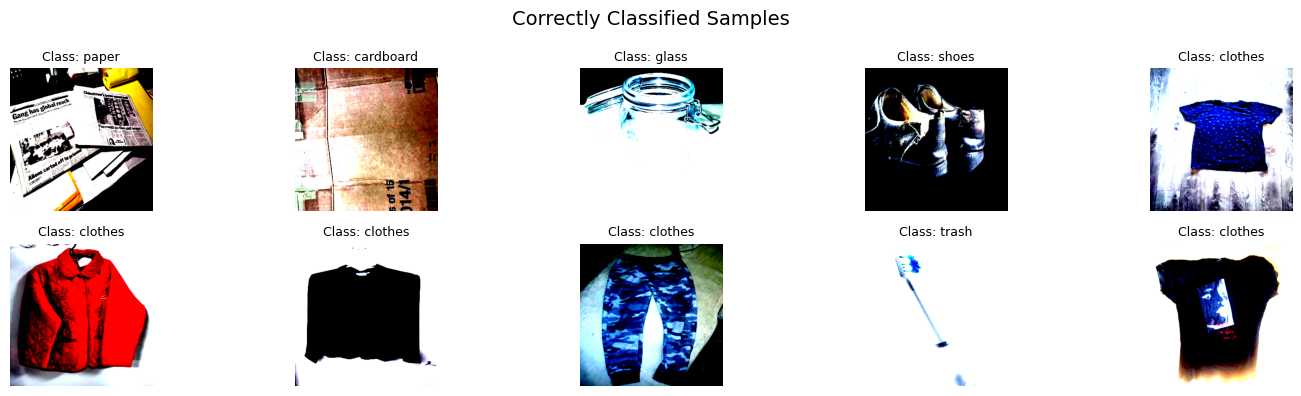

In [41]:
correct_idx = np.where(y_true == y_pred)[0]
np.random.seed(42)
sample_idx = np.random.choice(correct_idx, size=10, replace=False)

plt.figure(figsize=(15,4))
for i, idx in enumerate(sample_idx):
    img, _ = test_dataset[idx]
    img = img.permute(1,2,0).numpy()

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(
        f"Class: {train_dataset.classes[y_true[idx]]}",
        fontsize=9
    )
    plt.axis("off")

plt.suptitle("Correctly Classified Samples", fontsize=14)
plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.3060222].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1134453].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.4831376].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5185376..2.5005665].
C

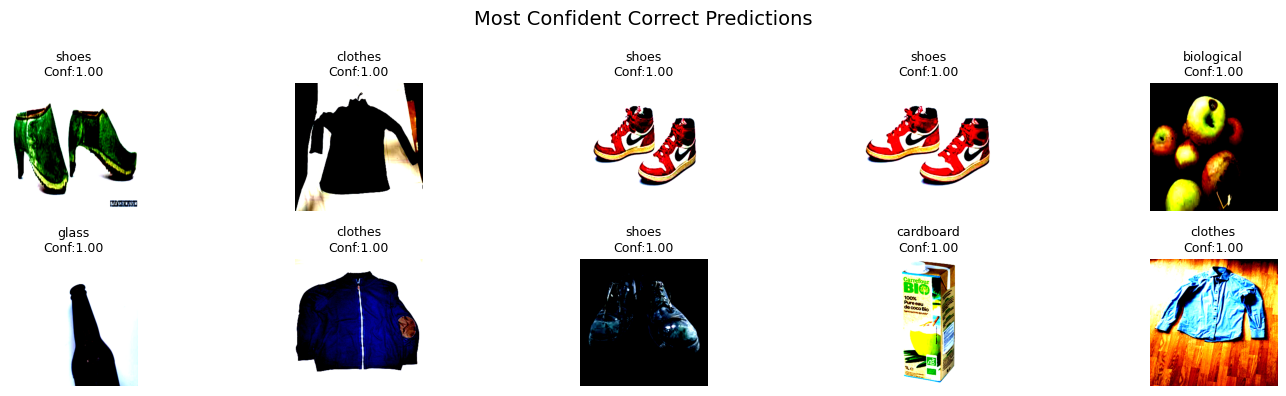

In [42]:
confidences = np.max(y_prob, axis=1)
correct_idx = np.where(y_true == y_pred)[0]

top_confident = correct_idx[np.argsort(confidences[correct_idx])[::-1][:10]]

plt.figure(figsize=(15,4))
for i, idx in enumerate(top_confident):
    img, _ = test_dataset[idx]
    img = img.permute(1,2,0).numpy()

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(
        f"{train_dataset.classes[y_true[idx]]}\nConf:{confidences[idx]:.2f}",
        fontsize=9
    )
    plt.axis("off")

plt.suptitle("Most Confident Correct Predictions", fontsize=14)
plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..1.9577874].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0182073..2.1834733].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5630252..2.5877128].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.343704].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5081482..2.2914162].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.6

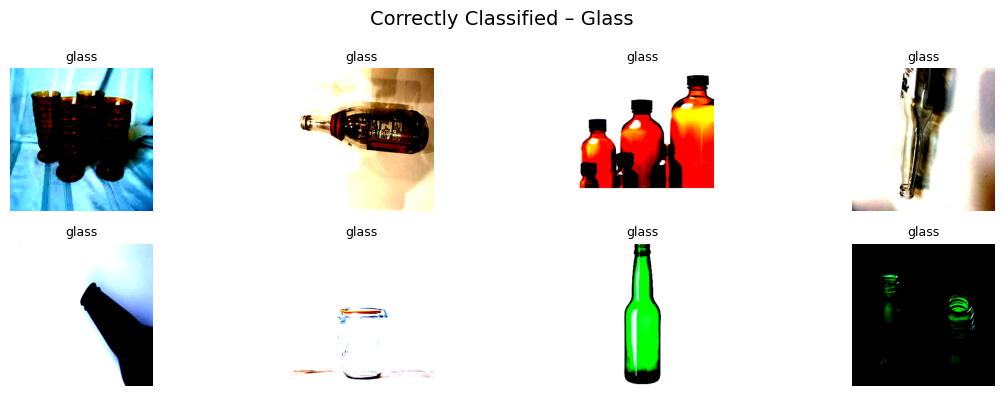

In [43]:
target_class = train_dataset.classes.index("glass")

filtered = [
    i for i in range(len(y_true))
    if y_true[i] == target_class and y_pred[i] == target_class
][:8]

plt.figure(figsize=(12,4))
for i, idx in enumerate(filtered):
    img, _ = test_dataset[idx]
    img = img.permute(1,2,0).numpy()

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title("glass", fontsize=9)
    plt.axis("off")

plt.suptitle("Correctly Classified – Glass", fontsize=14)
plt.tight_layout()
plt.show()

In [50]:
import torch
torch.save(model, 'garbage_inception_full.pth')

In [51]:
import os
print(os.getcwd())

C:\Users\Lenovo
